In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from conditional_vit_generator import AutoregressiveDecoder, load_fashion_mnist, train_generator, NUM_PATCHES

tf.random.set_seed(0)
np.random.seed(0)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


In [2]:
(x_train, y_train), (x_test, y_test) = load_fashion_mnist()
model = AutoregressiveDecoder()
losses = train_generator(model, x_train, y_train, epochs=10, batch_size=128)


epoch 1/10  loss=0.2137
epoch 2/10  loss=0.1140
epoch 3/10  loss=0.0933
epoch 4/10  loss=0.0833
epoch 5/10  loss=0.0756
epoch 6/10  loss=0.0727
epoch 7/10  loss=0.0675
epoch 8/10  loss=0.0647
epoch 9/10  loss=0.0665
epoch 10/10  loss=0.0609


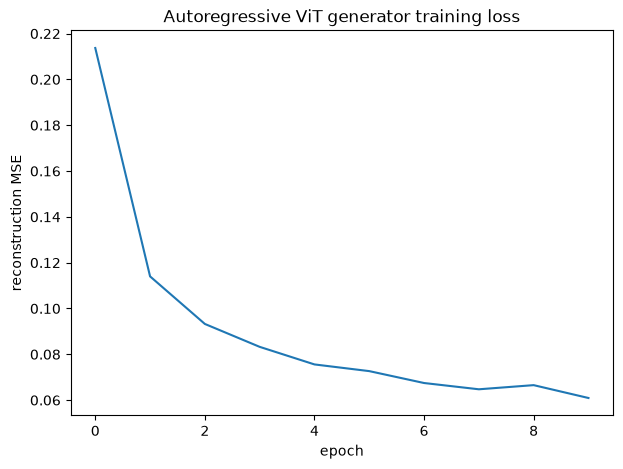

In [3]:
plt.figure(figsize=(7, 5))
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("reconstruction MSE")
plt.title("Autoregressive ViT generator training loss")
plt.show()


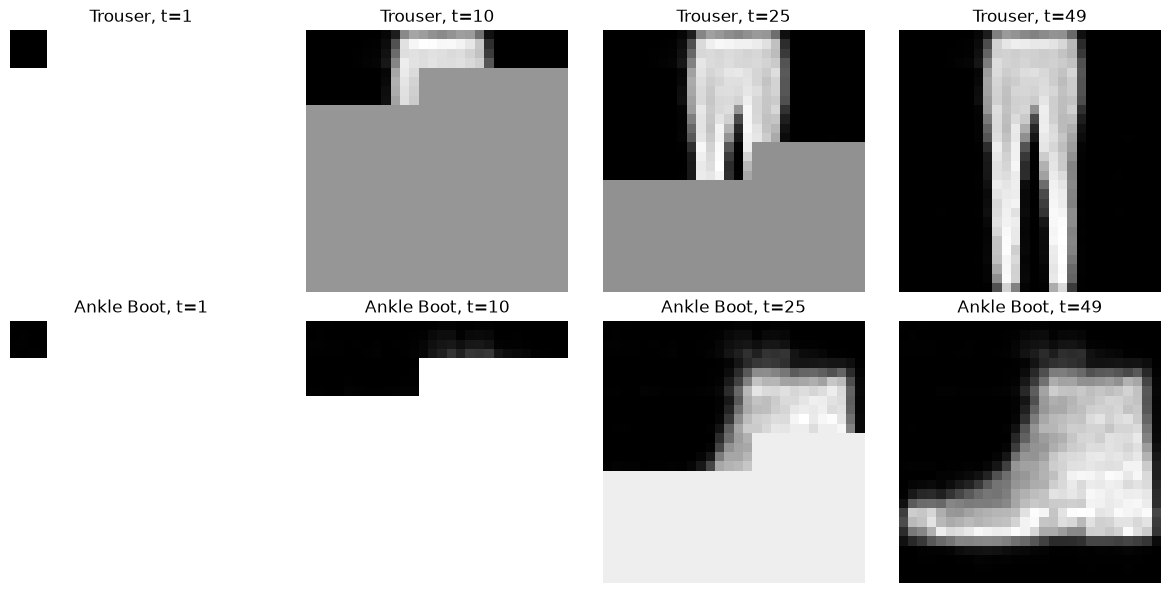

In [4]:
trouser_label = tf.constant([1])
boot_label = tf.constant([9])

_, trouser_steps = model.generate(trouser_label)
_, boot_steps = model.generate(boot_label)

step_keys = [1, 10, 25, NUM_PATCHES]
fig, axes = plt.subplots(2, len(step_keys), figsize=(3 * len(step_keys), 6))
for col, step in enumerate(step_keys):
    axes[0, col].imshow((trouser_steps[step][0, ..., 0].numpy() + 1) / 2, cmap="gray")
    axes[0, col].set_title(f"Trouser, t={step}")
    axes[0, col].axis("off")

    axes[1, col].imshow((boot_steps[step][0, ..., 0].numpy() + 1) / 2, cmap="gray")
    axes[1, col].set_title(f"Ankle Boot, t={step}")
    axes[1, col].axis("off")
plt.tight_layout()
plt.show()


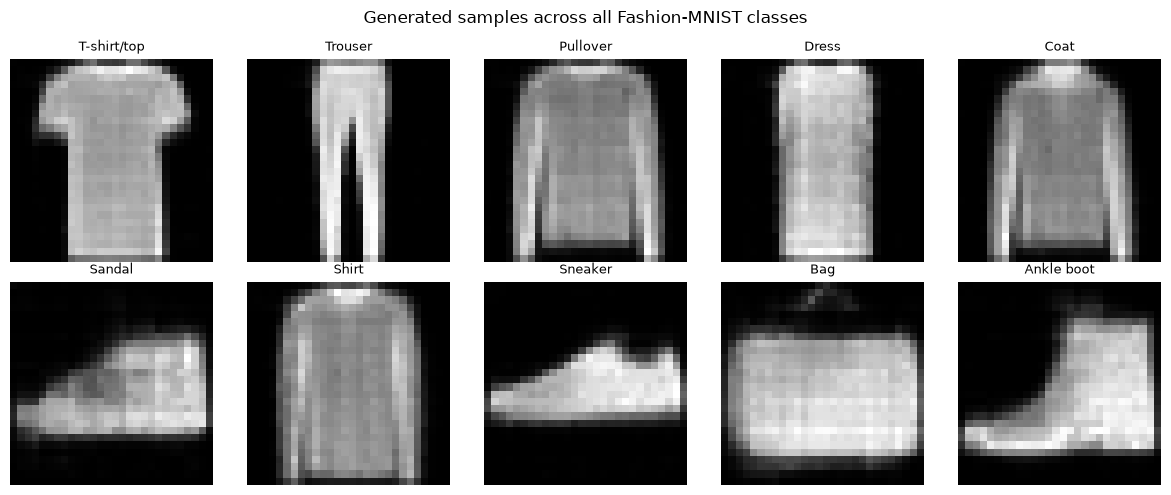

In [5]:
n_classes_to_show = 10
labels_all = tf.constant(list(range(n_classes_to_show)))
final_images, _ = model.generate(labels_all)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow((final_images[i, ..., 0].numpy() + 1) / 2, cmap="gray")
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis("off")
plt.suptitle("Generated samples across all Fashion-MNIST classes")
plt.tight_layout()
plt.show()
